In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Cargamos los datos listos
df = pd.read_csv('../data/processed/coffee_preprocessed.csv')

# 2. Separamos X (características) e y (objetivo)
X = df.drop(columns=['is_specialty'])
y = df['is_specialty']

# 3. Dividimos: 80% para aprender (train) y 20% para examen (test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Entrenamiento: {X_train.shape[0]} muestras | Prueba: {X_test.shape[0]} muestras")

✅ Entrenamiento: 1214 muestras | Prueba: 304 muestras


In [3]:
# Creamos el modelo con una profundidad máxima de 3 para que sea interpretable
arbol_modelo = DecisionTreeClassifier(max_depth=3, random_state=42)

# Entrenamos a la IA
arbol_modelo.fit(X_train, y_train)

print("✅ ¡IA entrenada con éxito!")

✅ ¡IA entrenada con éxito!


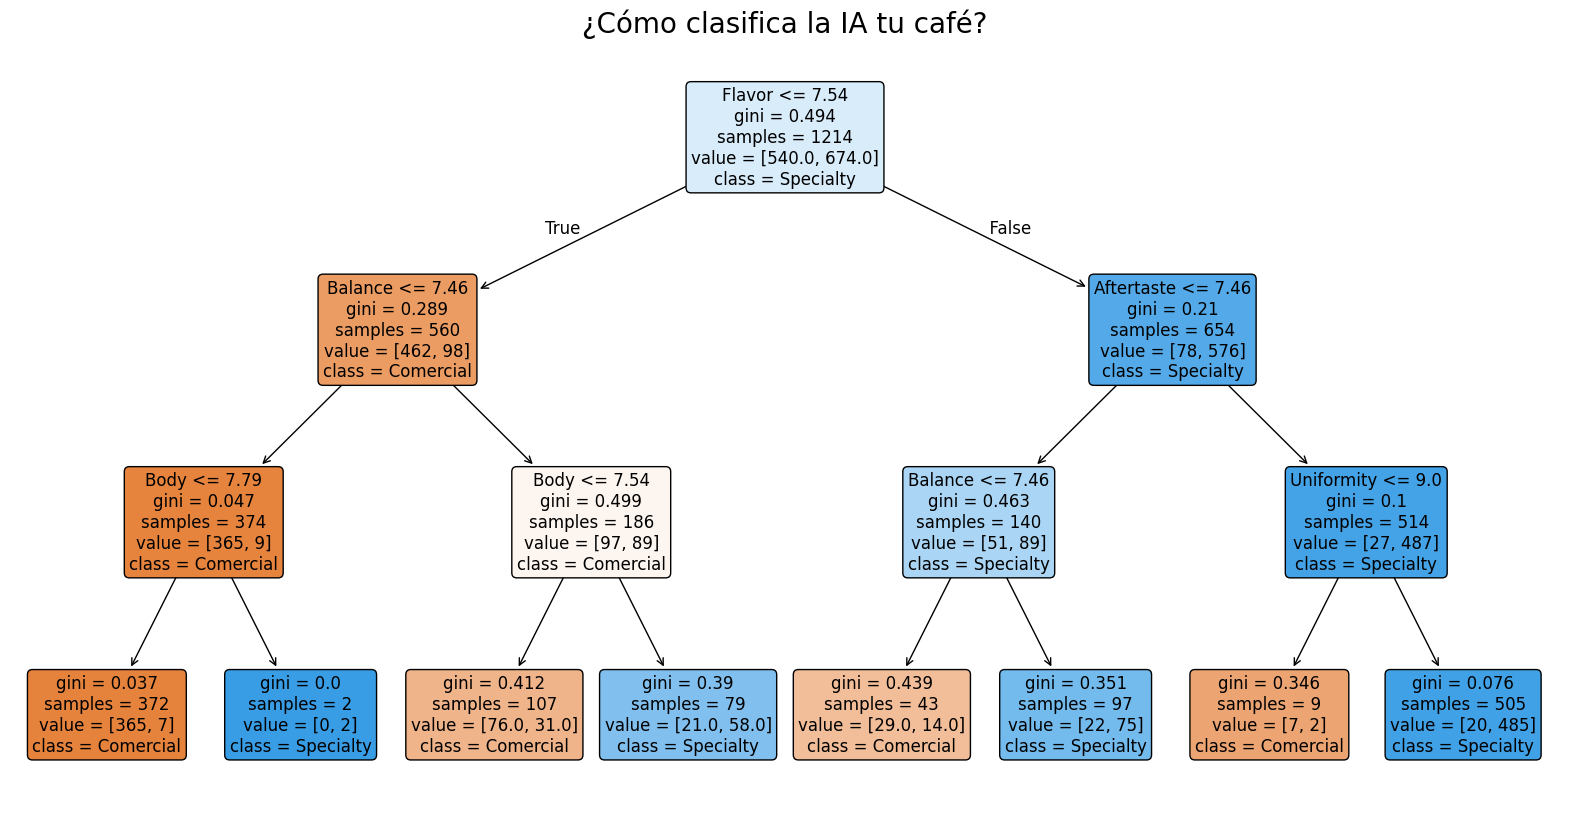

In [4]:
plt.figure(figsize=(20,10))
plot_tree(arbol_modelo, 
          feature_names=X.columns, 
          class_names=['Comercial', 'Specialty'], 
          filled=True, 
          rounded=True,
          fontsize=12)
plt.title("¿Cómo clasifica la IA tu café?", fontsize=20)
plt.show()

📊 RESULTADOS DEL MODELO:
              precision    recall  f1-score   support

           0       0.94      0.85      0.89       141
           1       0.88      0.95      0.91       163

    accuracy                           0.90       304
   macro avg       0.91      0.90      0.90       304
weighted avg       0.91      0.90      0.90       304



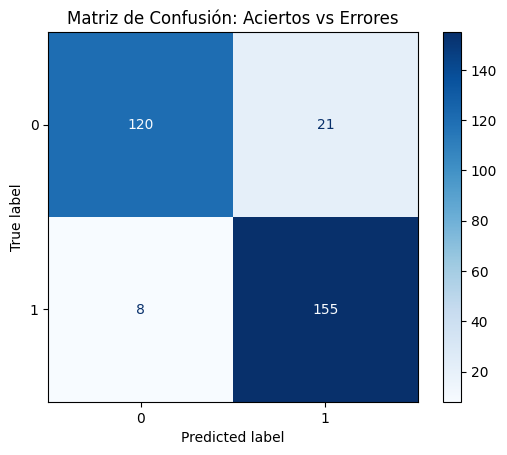

In [5]:
# Hacemos el examen
y_pred = arbol_modelo.predict(X_test)

# Mostramos resultados técnicos
print("📊 RESULTADOS DEL MODELO:")
print(classification_report(y_test, y_pred))

# Graficamos la matriz de confusión
ConfusionMatrixDisplay.from_estimator(arbol_modelo, X_test, y_test, cmap='Blues')
plt.title("Matriz de Confusión: Aciertos vs Errores")
plt.show()

🌳 EVALUACIÓN FINAL: ÁRBOL DE DECISIÓN
----------------------------------------
 Métrica  Resultado
Accuracy     0.9046
F1-Score     0.9145
 ROC AUC     0.9535
----------------------------------------


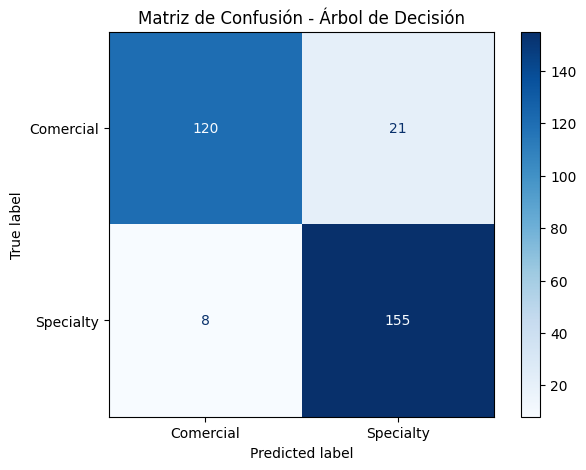

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

# 1. Obtener predicciones y probabilidades del ÁRBOL
y_pred = arbol_modelo.predict(X_test)
y_probs = arbol_modelo.predict_proba(X_test)[:, 1]

# 2. Crear tabla de indicadores (DNI del modelo)
indicadores_arbol = pd.DataFrame({
    'Métrica': ['Accuracy', 'F1-Score', 'ROC AUC'],
    'Resultado': [
        accuracy_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_probs)
    ]
})

# 3. Mostrar resultados y Matriz de Confusión 
print("🌳 EVALUACIÓN FINAL: ÁRBOL DE DECISIÓN")
print("-" * 40)
print(indicadores_arbol.round(4).to_string(index=False))
print("-" * 40)

# Graficamos la Matriz
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, 
                                        display_labels=['Comercial', 'Specialty'], 
                                        cmap='Blues', 
                                        ax=ax)
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.show()

🚀 EVALUACIÓN FINAL: XGBOOST
----------------------------------------
 Métrica  Resultado
Accuracy     0.9507
F1-Score     0.9552
 ROC AUC     0.9904
----------------------------------------


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [12:18:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


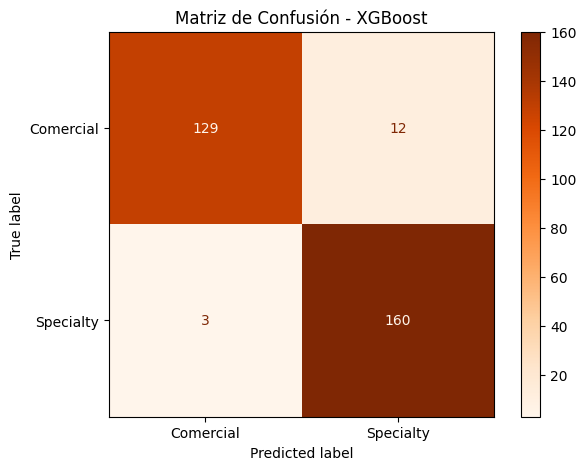

In [16]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Configurar y entrenar el modelo XGBoost
# Usamos parámetros estándar que suelen funcionar muy bien con datos tabulares
modelo_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

modelo_xgb.fit(X_train, y_train)

# 2. Obtener predicciones y probabilidades
y_pred_xgb = modelo_xgb.predict(X_test)
y_probs_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

# 3. Crear tabla de indicadores consolidados
resumen_xgb = pd.DataFrame({
    'Métrica': ['Accuracy', 'F1-Score', 'ROC AUC'],
    'Resultado': [
        accuracy_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb),
        roc_auc_score(y_test, y_probs_xgb)
    ]
})

# 4. Mostrar resultados y Matriz de Confusión
print("🚀 EVALUACIÓN FINAL: XGBOOST")
print("-" * 40)
print(resumen_xgb.round(4).to_string(index=False))
print("-" * 40)

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, 
                                        display_labels=['Comercial', 'Specialty'], 
                                        cmap='Oranges', 
                                        ax=ax)
plt.title('Matriz de Confusión - XGBoost')
plt.show()

🏆 TABLA COMPARATIVA DE RENDIMIENTO
--------------------------------------------------
           Modelo  Accuracy  F1-Score  ROC AUC
Árbol de Decisión    0.9046    0.9145   0.9535
          XGBoost    0.9507    0.9552   0.9904
--------------------------------------------------


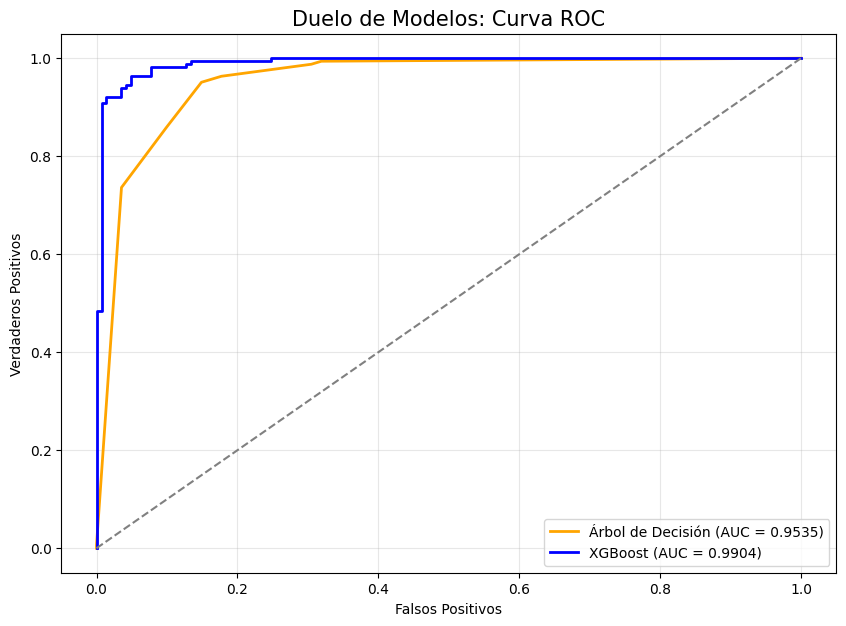

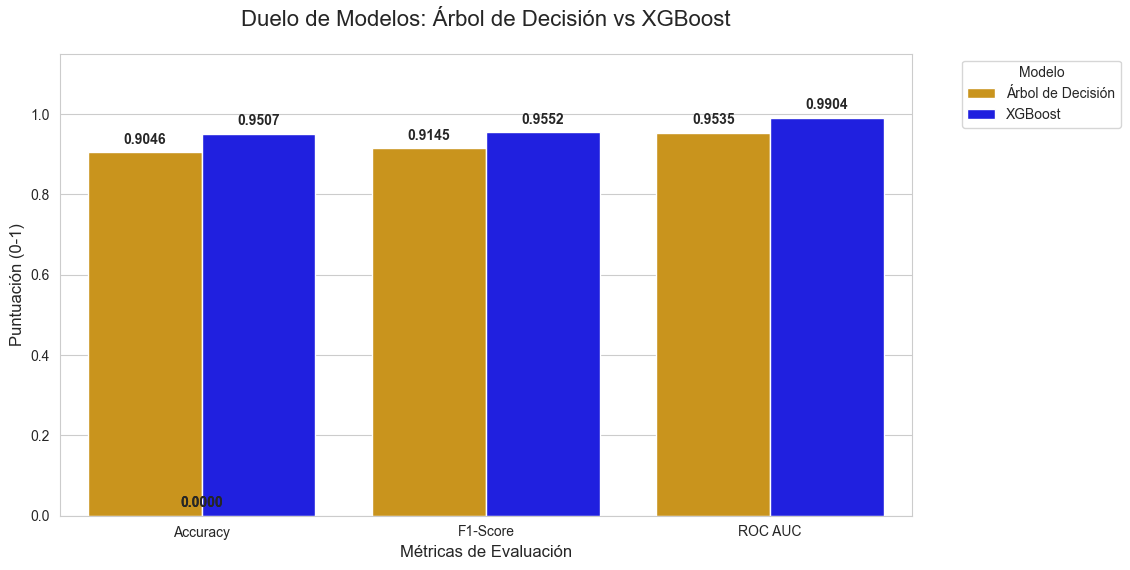

In [19]:
# 1. Calculamos todas las métricas para ambos modelos
modelos = {
    'Árbol de Decisión': (arbol_modelo, 'orange'),
    'XGBoost': (modelo_xgb, 'blue')
}

resumen_final = []

plt.figure(figsize=(10, 7))

for nombre, (modelo, color) in modelos.items():
    # Predicciones y Probabilidades
    preds = modelo.predict(X_test)
    probs = modelo.predict_proba(X_test)[:, 1]
    
    # Métricas
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc_val = roc_auc_score(y_test, probs)
    
    resumen_final.append({
        'Modelo': nombre,
        'Accuracy': acc,
        'F1-Score': f1,
        'ROC AUC': auc_val
    })
    
    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC = {auc_val:.4f})')

# 2. Mostrar Tabla Comparativa
df_comparativa = pd.DataFrame(resumen_final)
print("🏆 TABLA COMPARATIVA DE RENDIMIENTO")
print("-" * 50)
print(df_comparativa.round(4).to_string(index=False))
print("-" * 50)

# 3. Personalizar el Gráfico
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('Duelo de Modelos: Curva ROC', fontsize=15)
plt.xlabel('Falsos Positivos')
plt.ylabel('Verdaderos Positivos')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparamos los datos de la tabla
data = {
    'Métrica': ['Accuracy', 'F1-Score', 'ROC AUC'],
    'Árbol de Decisión': [0.9046, 0.9145, 0.9535],
    'XGBoost': [0.9507, 0.9552, 0.9904]
}

df_comp = pd.DataFrame(data)
# Transformamos a formato "largo" para Seaborn
df_melted = df_comp.melt(id_vars='Métrica', var_name='Modelo', value_name='Resultado')

# 2. Creamos el gráfico de barras
plt.figure(figsize=(11, 6))
sns.set_style("whitegrid")
barplot = sns.barplot(data=df_melted, x='Métrica', y='Resultado', hue='Modelo', palette=['#E69F00', '#0000FF'])

# 3. Añadimos las etiquetas de valor sobre cada barra
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.4f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=10, fontweight='bold')

# 4. Personalización final
plt.ylim(0, 1.15) # Espacio extra para las etiquetas
plt.title('Duelo de Modelos: Árbol de Decisión vs XGBoost', fontsize=16, pad=20)
plt.ylabel('Puntuación (0-1)', fontsize=12)
plt.xlabel('Métricas de Evaluación', fontsize=12)
plt.legend(title='Modelo', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()


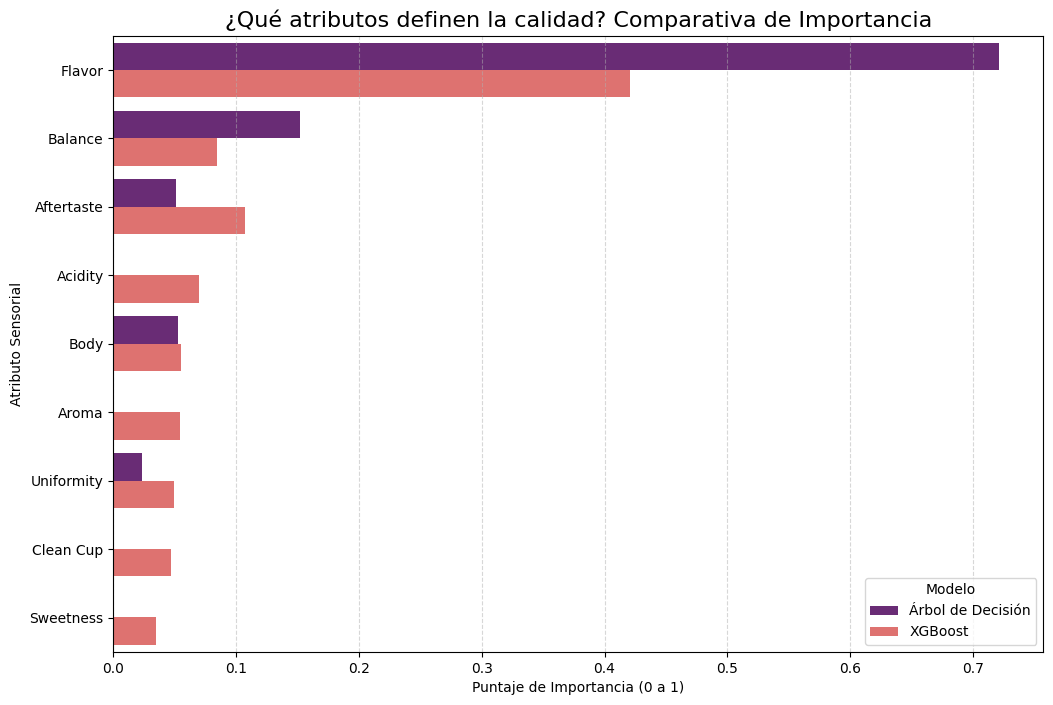

📌 TOP 3 VARIABLES SEGÚN CADA MODELO:
🌳 Árbol: ['Flavor', 'Balance', 'Body']
🚀 XGBoost: ['Flavor', 'Aftertaste', 'Balance']


In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Creamos un DataFrame con las importancias de ambos modelos
importancias = pd.DataFrame({
    'Atributo': X.columns,
    'Árbol de Decisión': arbol_modelo.feature_importances_,
    'XGBoost': modelo_xgb.feature_importances_
})

# Lo ponemos en formato "largo" para graficarlo fácilmente con Seaborn
importancias_melted = importancias.melt(id_vars='Atributo', var_name='Modelo', value_name='Importancia')

# 2. Graficamos el Top 7 de variables
plt.figure(figsize=(12, 8))
sns.barplot(
    data=importancias_melted.sort_values(by='Importancia', ascending=False).head(14),
    x='Importancia', y='Atributo', hue='Modelo', palette='magma'
)

plt.title('¿Qué atributos definen la calidad? Comparativa de Importancia', fontsize=16)
plt.xlabel('Puntaje de Importancia (0 a 1)')
plt.ylabel('Atributo Sensorial')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

# 3. Resumen en texto
print("📌 TOP 3 VARIABLES SEGÚN CADA MODELO:")
print(f"🌳 Árbol: {importancias.sort_values(by='Árbol de Decisión', ascending=False)['Atributo'].head(3).tolist()}")
print(f"🚀 XGBoost: {importancias.sort_values(by='XGBoost', ascending=False)['Atributo'].head(3).tolist()}")